In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh
from scripts.bat_class import BatOsc, bat_from_json, Ball, ball_from_json
from scripts.plot_osc import plot_batsol_heatmap, plot_bat, colors 
from scripts.create_system_matrix import plot_mode_shapes, find_mode_nodes, plot_mode_shapes_compare
from scripts.eigenstuff import compute_eigenfrequencies

## **Get Slice Time Series**

/Users/navawolfish/Desktop/baseball/AlanProject/scripts/eigenstuff.py:23: RuntimeWarning: invalid value encountered in sqrt
  'frequency_Hz': np.where(evals.real < 0, np.sqrt(-evals.real) / (2 * np.pi), 0),


No solution found, plotting static bat.


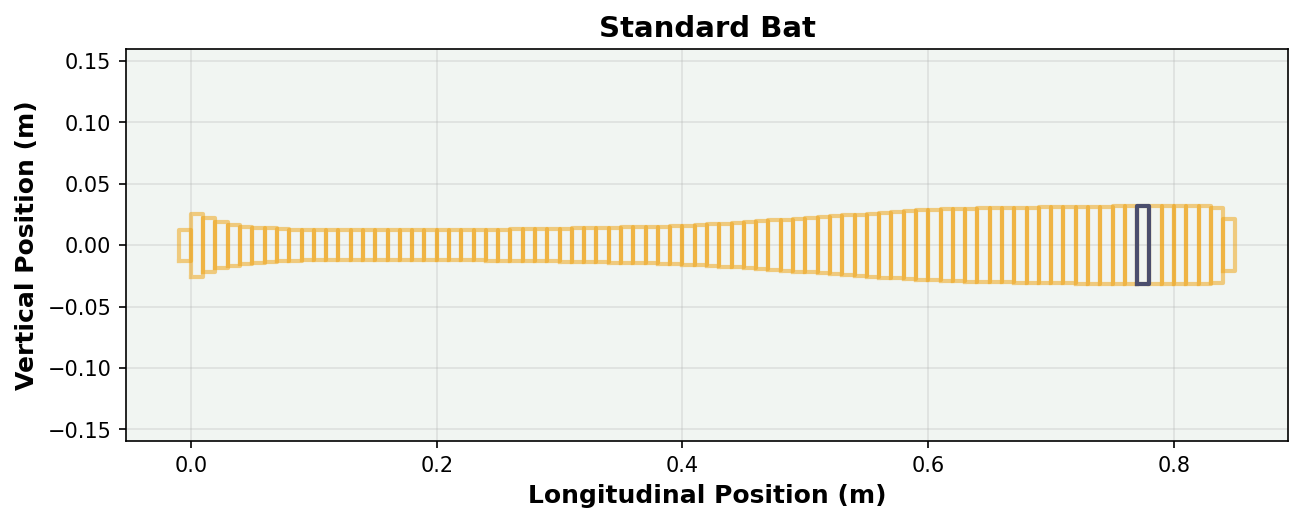

No solution found, plotting static bat.


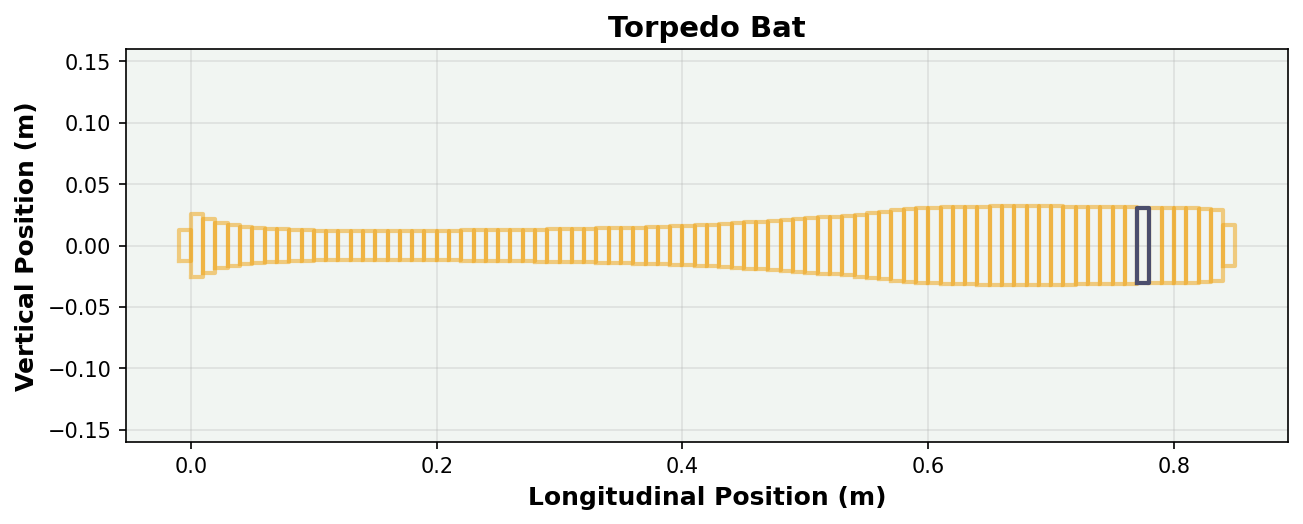

In [15]:
## take a sample of the data
sim_key = 'Adley'
standard_bat = bat_from_json(f'data/bats/AdleyOld.json')
torpedo_bat = bat_from_json(f'data/bats/AdleyNewMod2.json')

ball = ball_from_json('data/balls/Adley_ball.json')

impact_idx = 78 # index of the impact location in the bat's z array

plot_bat(standard_bat, highlight = impact_idx, title='Standard Bat')
plot_bat(torpedo_bat, highlight = impact_idx, title='Torpedo Bat')

In [17]:
inits = np.zeros((4* standard_bat.N)) # initial conditions for the bat oscillation (N slices, 4 variables each)

standard_bat.get_H_matrix()
torpedo_bat.get_H_matrix()

standard_bat.set_initial_conditions(inits)
torpedo_bat.set_initial_conditions(inits)

standard_bat.ball = ball
torpedo_bat.ball = ball


tspan = (0, 0.01) # time span for the integration
t_eval = np.linspace(tspan[0], tspan[1], 10000) # time points at which to evaluate the solution

standard_sol = standard_bat.integrate_with_ball(tspan, ball, impact_idx, t_eval, verbose=True, method = 'RK45')
standard_bat.ydot_sol = standard_sol['ydot_sol']
torpedo_sol = torpedo_bat.integrate_with_ball(tspan, ball, impact_idx, t_eval, verbose=True, method = 'RK45')
torpedo_bat.ydot_sol = torpedo_sol['ydot_sol']

Max compression at t = 0.432 ms: u_max = 12.767 mm, F_max = 18966.6 N, k2 = 1.83e+20
Ball separates at t = 1.136 ms, ball exit v = 3.61 m/s
Max compression at t = 0.430 ms: u_max = 12.671 mm, F_max = 18771.7 N, k2 = 1.93e+20
Ball separates at t = 1.142 ms, ball exit v = 3.01 m/s


## **Get H-Matrix Eigvals, Vecs**

In [18]:
num_modes = standard_bat.N

H_standard = standard_bat.H
H_torpedo = torpedo_bat.H

standard_bat.K = standard_bat.M @ H_standard
torpedo_bat.K = torpedo_bat.M @ H_torpedo

eig_dfS = compute_eigenfrequencies(standard_bat.K, standard_bat.M, num_modes=10)
#concatenate for first 10 non-rigid modes
eig_dfS = eig_dfS.iloc[0:num_modes].reset_index(drop=True)
eig_dfT = compute_eigenfrequencies(torpedo_bat.K, torpedo_bat.M, num_modes=10)
eig_dfT = eig_dfT.iloc[0:num_modes].reset_index(drop=True)

/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_68414/2591606089.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eig_dfS.iloc[i][ 'eigenvector'] = list(standard_modes[:, i])
/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_68414/2591606089.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eig_dfT.iloc[i][ 'eigenvector'] = list(torpedo_modes[:, i])


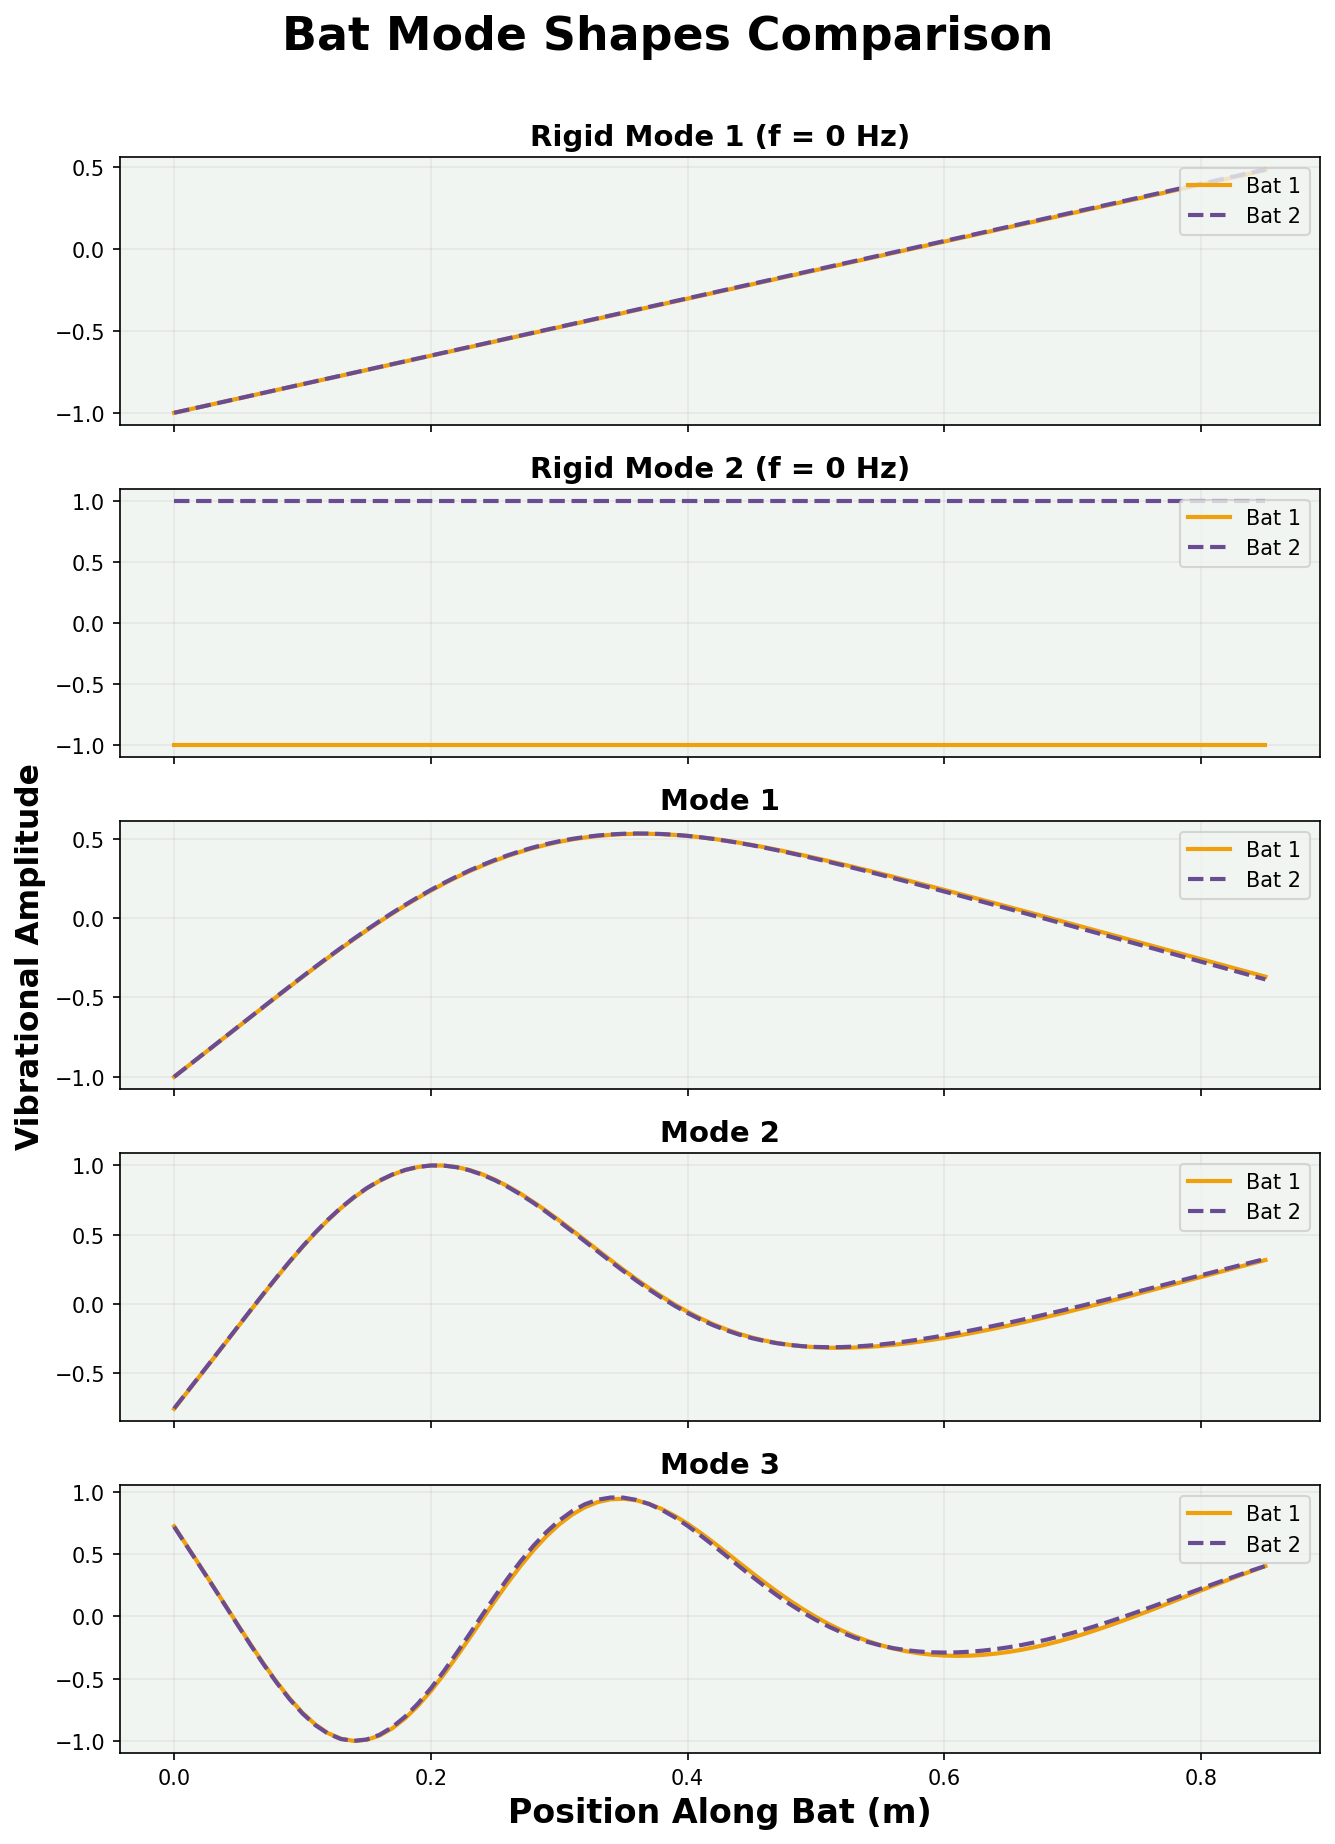

In [19]:
standard_modes = np.stack(eig_dfS['eigenvector'].values, axis=1)  # (2N, 10)
torpedo_modes = np.stack(eig_dfT['eigenvector'].values, axis=1)  # (2N, 10)

#now normalize wrt M
standard_modes = standard_modes / np.sqrt(np.sum(standard_modes * (standard_bat.M @ standard_modes), axis=0))
torpedo_modes = torpedo_modes / np.sqrt(np.sum(torpedo_modes * (torpedo_bat.M @ torpedo_modes), axis=0))

standard_omega = eig_dfS['frequency_Hz'].values * 2 * np.pi
torpedo_omega = eig_dfT['frequency_Hz'].values * 2 * np.pi

#back into eig_dfs
for i in range(10):
    eig_dfS.iloc[i][ 'eigenvector'] = list(standard_modes[:, i])
    eig_dfT.iloc[i][ 'eigenvector'] = list(torpedo_modes[:, i])

plot_mode_shapes_compare([eig_dfS, eig_dfT], [standard_bat.zs, torpedo_bat.zs], [standard_bat.N, torpedo_bat.N])
plt.show()

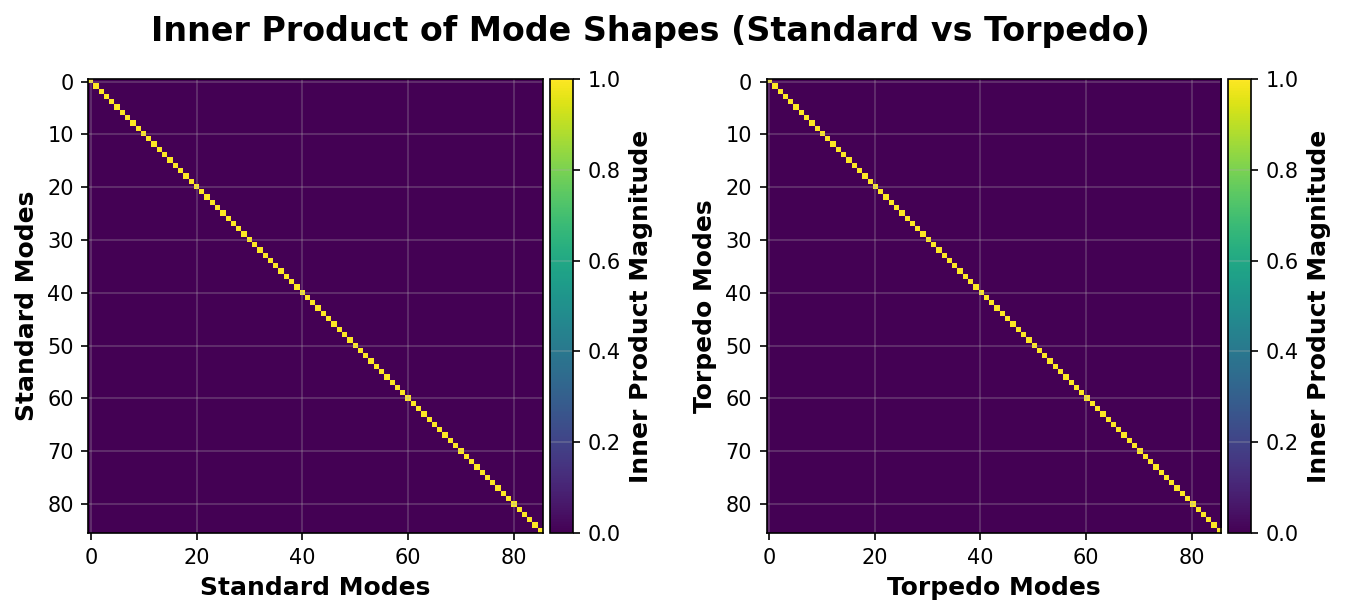

In [20]:
#plot heatmap of the inner product of the first 10 modes of each bat
from mpl_toolkits.axes_grid1 import make_axes_locatable

inner_product_standard = np.abs(standard_modes.T @ (standard_bat.M @ standard_modes))
inner_product_torpedo = np.abs(torpedo_modes.T @ (torpedo_bat.M @ torpedo_modes))

# Get the same scale for both colorbars
vmin = min(inner_product_standard.min(), inner_product_torpedo.min())
vmax = max(inner_product_standard.max(), inner_product_torpedo.max())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(inner_product_standard, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
ax[0].set_xlabel('Standard Modes')
ax[0].set_ylabel('Standard Modes')
ax[0].set_aspect('equal')
divider0 = make_axes_locatable(ax[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, label='Inner Product Magnitude', cax=cax0)

im1 = ax[1].imshow(inner_product_torpedo, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
ax[1].set_xlabel('Torpedo Modes')
ax[1].set_ylabel('Torpedo Modes')
ax[1].set_aspect('equal')
divider1 = make_axes_locatable(ax[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, label='Inner Product Magnitude', cax=cax1)
fig.suptitle('Inner Product of Mode Shapes (Standard vs Torpedo)', fontsize=16, fontweight='bold')
fig.subplots_adjust(wspace=0.4)

## **Examine $y$-Slice Solutions**

### **Get Constant $\bar{A}$**

In [21]:
#now get Abar for the standard bat
stan_Ai = standard_bat.radii**2 * np.pi
standard_ymodes = standard_modes[:standard_bat.N, :]  # only take the y-displacement part of the modes
assert standard_ymodes.shape == (standard_bat.N, num_modes) # sanity check

standard_Abar = (standard_ymodes.T @ (stan_Ai[:, None] * standard_bat.dz * standard_ymodes)) #area norm matrix

torp_Ai = torpedo_bat.radii**2 * np.pi
torpedo_ymodes = torpedo_modes[:torpedo_bat.N, :]  # only take the y-displacement part of the modes
assert torpedo_ymodes.shape == (torpedo_bat.N, num_modes) # sanity check


torp_Abar = (torpedo_ymodes.T @ (torp_Ai[:, None] * torpedo_bat.dz * torpedo_ymodes)) #area norm matrix

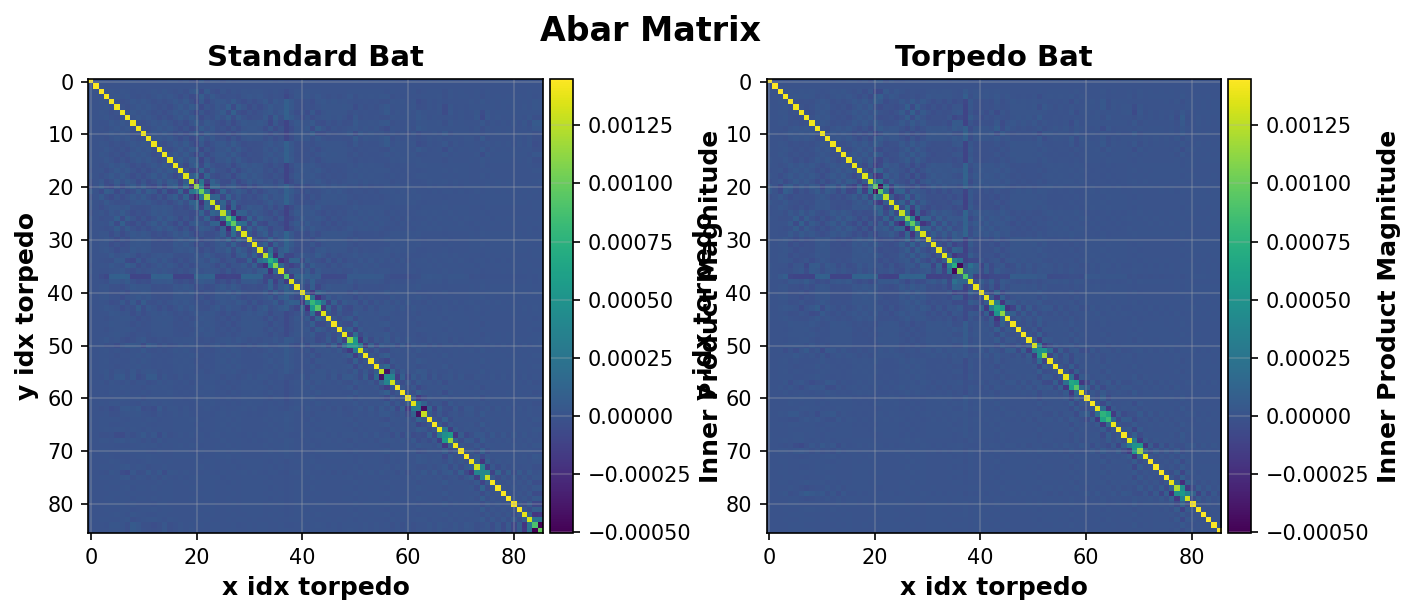

In [22]:

# Get the same scale for both colorbars
vmin = min(standard_Abar.min(), torp_Abar.min())
vmax = max(standard_Abar.max(), torp_Abar.max())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(standard_Abar, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
ax[0].set_xlabel('x idx torpedo')
ax[0].set_ylabel('y idx torpedo')
ax[0].set_aspect('equal')
divider0 = make_axes_locatable(ax[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im0, label='Inner Product Magnitude', cax=cax0)
ax[0].set_title('Standard Bat')

im1 = ax[1].imshow(torp_Abar, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
ax[1].set_xlabel('x idx torpedo')
ax[1].set_ylabel('y idx torpedo')
ax[1].set_aspect('equal')
ax[1].set_title('Torpedo Bat')
divider1 = make_axes_locatable(ax[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, label='Inner Product Magnitude', cax=cax1)
fig.suptitle('Abar Matrix', fontsize=16, fontweight='bold')
fig.subplots_adjust(wspace=0.4)

In [23]:
#all vals should be same on diagonal
standard_Abar = np.diag(standard_Abar)[0]
torp_Abar = np.diag(torp_Abar)[0]

## **Get $a_n(t)$**

In [24]:
def get_an(y, mode_shapes, M):
    """Project the solution y onto the mode shape to get the modal amplitude an."""
    return mode_shapes.T @ M @ y

#get just the y part of M
standard_My = standard_bat.M[:standard_bat.N, :standard_bat.N]
torpedo_My = torpedo_bat.M[:torpedo_bat.N, :torpedo_bat.N]

standard_an = get_an(standard_bat.y_sol, standard_ymodes, standard_My)
torpedo_an = get_an(torpedo_bat.y_sol, torpedo_ymodes, torpedo_My)

standard_adotn = get_an(standard_bat.ydot_sol, standard_ymodes, standard_My)
torpedo_adotn = get_an(torpedo_bat.ydot_sol, torpedo_ymodes, torpedo_My)

## **Energy per Mode**

In [25]:
standard_E_n = 0.5 * standard_bat.rho * standard_Abar * (standard_adotn**2 + standard_omega[:, None]**2 * standard_an**2)

torpedo_E_n = 0.5 * torpedo_bat.rho * torp_Abar * (torpedo_adotn**2 + torpedo_omega[:, None]**2 * torpedo_an**2)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_modes_num = 4
colors_magma = plt.cm.magma(np.linspace(0, 1, plot_modes_num)) #
colors_viridis = plt.cm.viridis(np.linspace(0, 1, plot_modes_num)) #

# Plot each mode with a different color from magma
for i in range(plot_modes_num):
    ax.plot(t_eval, standard_E_n[i + 2, :], label=f'Mode {i + 1} (Standard)', color=colors_magma[i], linewidth=1.5)
    # ax.plot(t_eval, torpedo_E_n[i + 2, :], label=f'Mode {i + 1} (Torpedo)', color=colors_viridis[i], linestyle='--', linewidth=1.5)

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Modal Amplitude', fontsize=12)
ax.axvline(standard_bat.ball.t_collision, color='red', linestyle='--', label='Impact Time')
ax.set_xlim(0, 0.002)
ax.set_title('Standard Bat - Vibrational Energy', fontsize=14)
ax.legend(loc='best', ncol=2, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

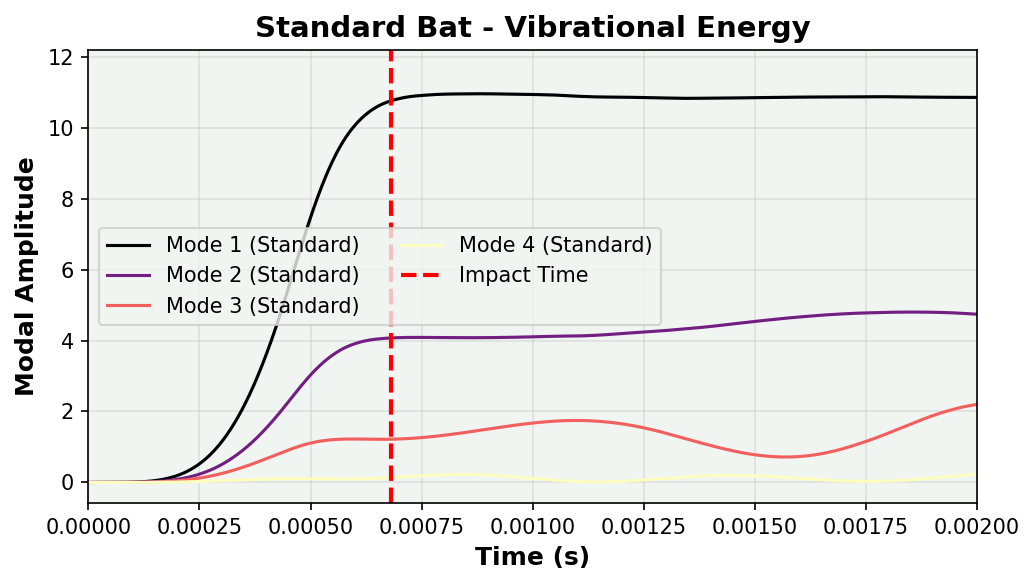

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_modes_num = 4
colors_magma = plt.cm.magma(np.linspace(0, 1, plot_modes_num)) #
colors_viridis = plt.cm.viridis(np.linspace(0, 1, plot_modes_num)) #

# Plot each mode with a different color from magma
for i in range(plot_modes_num):
    ax.plot(t_eval, standard_E_n[i + 2, :], label=f'Mode {i + 1} (Standard)', color=colors_magma[i], linewidth=1.5)
    # ax.plot(t_eval, torpedo_E_n[i + 2, :], label=f'Mode {i + 1} (Torpedo)', color=colors_viridis[i], linestyle='--', linewidth=1.5)

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Modal Amplitude', fontsize=12)
ax.axvline(standard_bat.ball.t_collision, color='red', linestyle='--', label='Impact Time')
ax.set_xlim(0, 0.002)
ax.set_title('Standard Bat - Vibrational Energy', fontsize=14)
ax.legend(loc='best', ncol=2, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()